# Model Comparison

This notebook runs the small classical model comparison pass from the documented plan.

It compares:

- `RandomForestClassifier`, `LogisticRegression`, `HistGradientBoostingClassifier`
- `RandomForestRegressor`, `Ridge`, `HistGradientBoostingRegressor`

Typical workflow:

1. Run the setup cell.
2. Run the dataset preview cell.
3. Run `COMPARISON_RESULT = run_default_model_comparison()`.
4. Inspect classifier and regressor result tables.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml.compare import run_model_comparison
from ml.features import find_latest_raw_csv, load_dataset_preview

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

DEFAULT_RAW_CSV = find_latest_raw_csv(REPO_ROOT / 'data' / 'raw')
DEFAULT_PROCESSED_ROOT = REPO_ROOT / 'data' / 'processed'
DEFAULT_RANDOM_SEED = 42

class NotebookProgress:
    def __init__(self, title):
        self.title = title
        self.handle = display(HTML(''), display_id=True)

    def update(self, payload):
        step = payload.get('step', 0)
        total = payload.get('total', 1)
        stage = payload.get('stage', '')
        message = payload.get('message', '')
        timestamp = payload.get('timestamp', '')
        percent = int(round((step / total) * 100)) if total else 100
        html = f'''<div style="border:1px solid #d0d7de;border-radius:10px;padding:12px 14px;margin:8px 0;background:#0f172a08;">\n  <div style="font-weight:600;margin-bottom:8px;">{self.title}</div>\n  <div style="height:12px;background:#e5e7eb;border-radius:999px;overflow:hidden;">\n    <div style="height:100%;width:{percent}%;background:linear-gradient(90deg,#16a34a,#06b6d4);transition:width 0.35s ease;"></div>\n  </div>\n  <div style="margin-top:8px;font-family:monospace;font-size:12px;">[{step}/{total}] {stage}</div>\n  <div style="margin-top:4px;">{message}</div>\n  <div style="margin-top:4px;color:#6b7280;font-size:12px;">{timestamp}</div>\n</div>'''
        self.handle.update(HTML(html))

def run_default_model_comparison(raw_csv_path=DEFAULT_RAW_CSV, processed_root=DEFAULT_PROCESSED_ROOT, random_seed=DEFAULT_RANDOM_SEED):
    progress = NotebookProgress('Model Comparison Progress')
    return run_model_comparison(
        raw_csv_path=raw_csv_path,
        processed_root=processed_root,
        random_seed=random_seed,
        progress_callback=progress.update,
    )

print('Repo root:', REPO_ROOT)
print('Default raw CSV:', DEFAULT_RAW_CSV)


Repo root: C:\Users\nayut\OneDrive\Документы\osu-skill-predictor
Default raw CSV: C:\Users\nayut\OneDrive\Документы\osu-skill-predictor\data\raw\osu_country_try_data_full_20260601T074107Z\osu_country_try_data_v1.csv


In [2]:
raw_preview = load_dataset_preview(DEFAULT_RAW_CSV, n_rows=5)
display(Markdown(f'**Raw CSV:** `{DEFAULT_RAW_CSV.relative_to(REPO_ROOT)}`'))
display(raw_preview)


**Raw CSV:** `data\raw\osu_country_try_data_full_20260601T074107Z\osu_country_try_data_v1.csv`

,row_id,score_id,user_id,beatmap_id,beatmapset_id,ruleset,collected_at,score_created_at,score_source,seed_country_code,seed_country_rank,seed_country_player_rank,seed_global_rank,target_passed,target_accuracy,score_rank,mods_raw,observed_pp,observed_max_combo,count_300,count_100,count_50,count_miss,user_pp,user_global_rank,user_country_rank,user_accuracy,user_play_count,user_play_time_sec,user_total_hits,user_maximum_combo,beatmap_star_rating,beatmap_bpm,beatmap_ar,beatmap_od,beatmap_cs,beatmap_hp,beatmap_hit_length_sec,beatmap_total_length_sec,beatmap_count_circles,beatmap_count_sliders,beatmap_count_spinners,beatmap_status,beatmap_passcount,beatmap_playcount
0,5019360540,5019360540,4175698,5258382,2401111,osu,2026-06-01T08:26:36Z,2026-05-02T18:53:54Z,best,US,1,1,7,True,97.0340,S,NC,1775.17,2427,1849,76,8,0,27431.8,7,1,97.1255,408850,11150983,61251422,3661,7.02593,190.00,9.5,9.2,4.0,5.0,238,260,1682,251,0,ranked,16908,182260
1,4934854295,4934854295,4175698,5211120,2191876,osu,2026-06-01T08:26:36Z,2025-11-08T00:54:22Z,best,US,1,1,7,True,98.4942,S,DT,1630.13,644,476,11,0,0,27431.8,7,1,97.1255,408850,11150983,61251422,3661,7.12841,200.00,9.7,9.5,4.3,5.0,58,59,393,94,0,ranked,17180,144559
2,4888133395,4888133395,4175698,5065131,2353052,osu,2026-06-01T08:26:36Z,2025-08-13T16:46:40Z,best,US,1,1,7,True,97.5970,A,NC,1608.47,2175,2502,87,4,1,27431.8,7,1,97.1255,408850,11150983,61251422,3661,6.73248,200.00,9.5,9.1,3.8,5.5,416,424,1914,679,1,ranked,8898,165331
3,4887078214,4887078214,4175698,4704022,2219231,osu,2026-06-01T08:26:36Z,2025-08-11T18:02:30Z,best,US,1,1,7,True,98.0301,S,DT,1515.03,2406,1783,48,5,0,27431.8,7,1,97.1255,408850,11150983,61251422,3661,6.34169,200.00,9.4,9.0,4.0,5.0,210,211,1598,238,0,ranked,44124,653617
4,4918857637,4918857637,4175698,5119288,2364885,osu,2026-06-01T08:26:36Z,2025-10-08T21:19:15Z,best,US,1,1,7,True,98.2456,S,DT,1464.59,1675,1221,33,0,0,27431.8,7,1,97.1255,408850,11150983,61251422,3661,6.60982,189.99,9.4,9.2,3.9,5.1,152,152,1071,182,1,ranked,30748,355825


In [3]:
COMPARISON_RESULT = run_default_model_comparison()
COMPARISON_RESULT['summary']


{'generated_at': '2026-06-06T18:49:50Z',
 'source_raw_csv': 'C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/data/raw/osu_country_try_data_full_20260601T074107Z/osu_country_try_data_v1.csv',
 'random_seed': 42,
 'classifier_primary_metric': 'pr_auc',
 'regressor_primary_metric': 'mae',
 'classifier_winner': 'HistGradientBoostingClassifier',
 'regressor_winner': 'HistGradientBoostingRegressor',
 'classifier_results_path': 'C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/data/processed/osu_country_try_data_full_20260601T074107Z/model_comparison_classifier.csv',
 'regressor_results_path': 'C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/data/processed/osu_country_try_data_full_20260601T074107Z/model_comparison_regressor.csv',
 'row_counts': {'loaded': 184615,
  'cleaned': 184229,
  'train': 147301,
  'test': 36928}}

In [4]:
summary_table = pd.DataFrame(
    [
        ('raw_csv_path', str(COMPARISON_RESULT['raw_csv_path'].relative_to(REPO_ROOT))),
        ('processed_dir', str(COMPARISON_RESULT['processed_dir'].relative_to(REPO_ROOT))),
        ('classifier_results_path', str(COMPARISON_RESULT['classifier_results_path'].relative_to(REPO_ROOT))),
        ('regressor_results_path', str(COMPARISON_RESULT['regressor_results_path'].relative_to(REPO_ROOT))),
        ('summary_path', str(COMPARISON_RESULT['summary_path'].relative_to(REPO_ROOT))),
        ('classifier_winner', COMPARISON_RESULT['summary']['classifier_winner']),
        ('regressor_winner', COMPARISON_RESULT['summary']['regressor_winner']),
    ],
    columns=['item', 'value'],
)
display(Markdown('## Comparison Summary'))
display(summary_table)

split_counts = pd.DataFrame(COMPARISON_RESULT['split_counts'].items(), columns=['split_name', 'rows'])
display(Markdown('## Split Counts'))
display(split_counts)


## Comparison Summary

,item,value
0,raw_csv_path,data\raw\osu_country_try_data_full_20260601T07...
1,processed_dir,data\processed\osu_country_try_data_full_20260...
2,classifier_results_path,data\processed\osu_country_try_data_full_20260...
3,regressor_results_path,data\processed\osu_country_try_data_full_20260...
4,summary_path,data\processed\osu_country_try_data_full_20260...
5,classifier_winner,HistGradientBoostingClassifier
6,regressor_winner,HistGradientBoostingRegressor


## Split Counts

,split_name,rows
0,train,147301
1,test,36928


In [5]:
classifier_results = COMPARISON_RESULT['classifier_results'].copy()
regressor_results = COMPARISON_RESULT['regressor_results'].copy()

display(Markdown('## Classifier Comparison'))
display(classifier_results)

display(Markdown('## Regressor Comparison'))
display(regressor_results)


## Classifier Comparison

,model_name,task,primary_metric_name,primary_metric_value,fit_seconds,predict_seconds,estimator_params,pr_auc,roc_auc,f1,precision,recall,positive_rate_test,predicted_positive_rate
0,HistGradientBoostingClassifier,classification,pr_auc,0.994410,1.408167,0.304606,"{'max_depth': 6, 'min_samples_leaf': 20, 'clas...",0.994410,0.766799,0.992666,0.986374,0.999038,0.985025,0.997671
1,RandomForestClassifier,classification,pr_auc,0.994238,3.698234,0.260144,"{'n_estimators': 120, 'max_depth': 20, 'min_sa...",0.994238,0.788871,0.991803,0.987411,0.996234,0.985025,0.993826
2,LogisticRegression,classification,pr_auc,0.993370,0.338911,0.100866,"{'class_weight': 'balanced', 'random_state': N...",0.993370,0.724397,0.818730,0.992443,0.696770,0.985025,0.691562


## Regressor Comparison

,model_name,task,primary_metric_name,primary_metric_value,fit_seconds,predict_seconds,estimator_params,mae,rmse,r2,prediction_min,prediction_max
0,HistGradientBoostingRegressor,regression,mae,3.414300,1.116813,0.132008,"{'max_depth': 6, 'min_samples_leaf': 20, 'rand...",3.414300,5.870452,0.687647,3.322250,102.603921
1,RandomForestRegressor,regression,mae,3.474767,14.834271,0.107334,"{'n_estimators': 120, 'max_depth': 20, 'min_sa...",3.474767,5.982957,0.675560,18.549253,99.985741
2,Ridge,regression,mae,3.850324,0.141614,0.025924,{'random_state': None},3.850324,6.333012,0.636484,-8.208755,117.028854


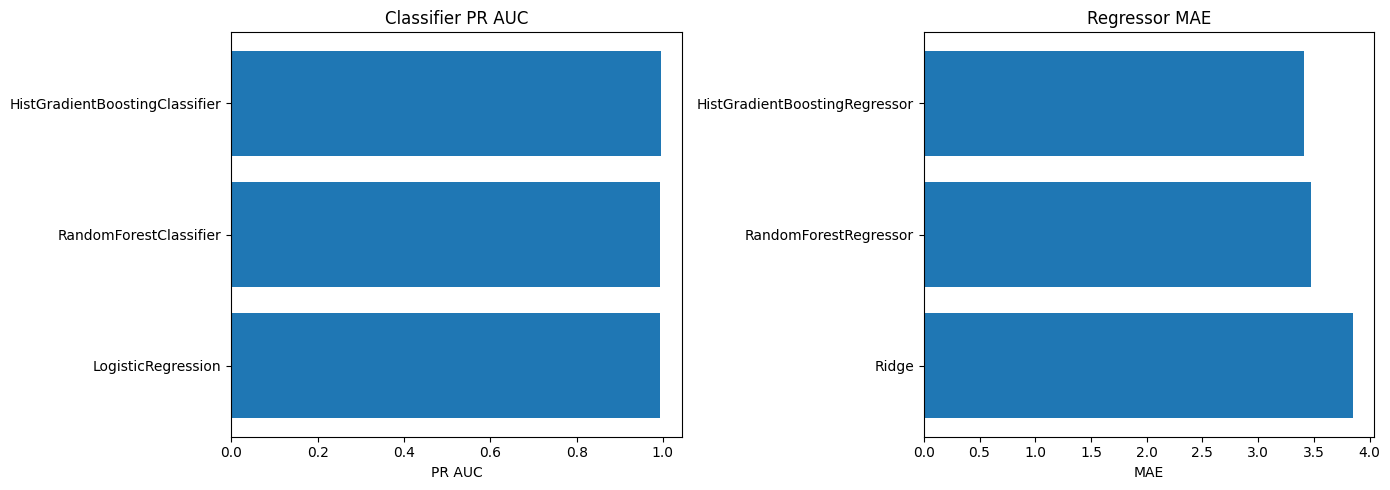

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classifier_plot = classifier_results.sort_values('pr_auc', ascending=True)
axes[0].barh(classifier_plot['model_name'], classifier_plot['pr_auc'])
axes[0].set_title('Classifier PR AUC')
axes[0].set_xlabel('PR AUC')

regressor_plot = regressor_results.sort_values('mae', ascending=False)
axes[1].barh(regressor_plot['model_name'], regressor_plot['mae'])
axes[1].set_title('Regressor MAE')
axes[1].set_xlabel('MAE')

plt.tight_layout()
plt.show()


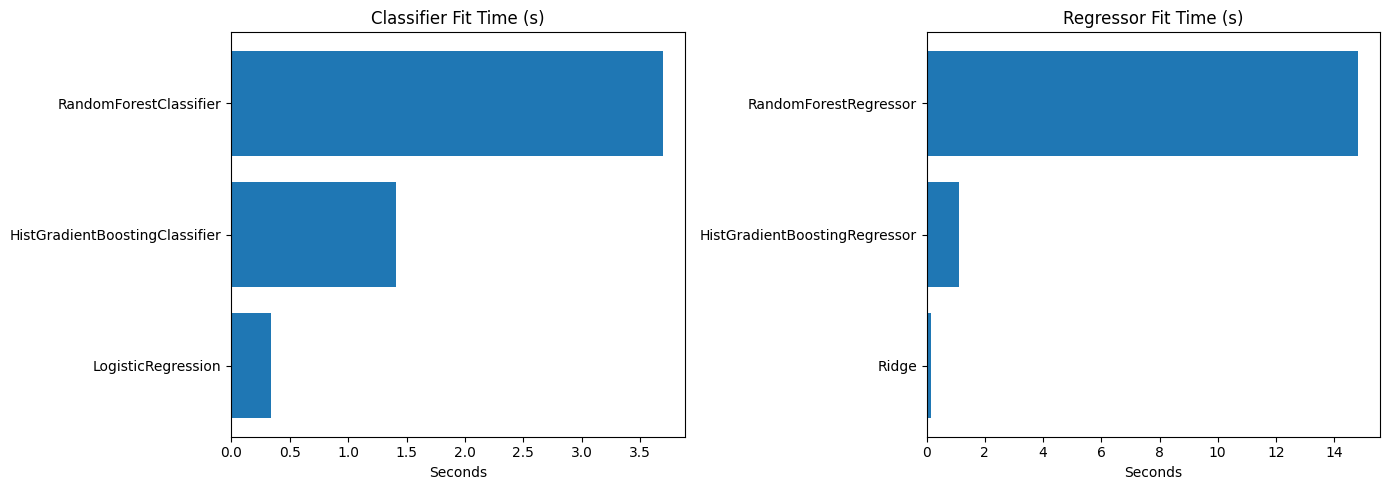

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classifier_timing = classifier_results.sort_values('fit_seconds', ascending=True)
axes[0].barh(classifier_timing['model_name'], classifier_timing['fit_seconds'])
axes[0].set_title('Classifier Fit Time (s)')
axes[0].set_xlabel('Seconds')

regressor_timing = regressor_results.sort_values('fit_seconds', ascending=True)
axes[1].barh(regressor_timing['model_name'], regressor_timing['fit_seconds'])
axes[1].set_title('Regressor Fit Time (s)')
axes[1].set_xlabel('Seconds')

plt.tight_layout()
plt.show()


In [8]:
comparison_summary = json.loads(Path(COMPARISON_RESULT['summary_path']).read_text(encoding='utf-8'))
display(Markdown('## Saved Comparison Summary JSON'))
display(comparison_summary)


## Saved Comparison Summary JSON

{'generated_at': '2026-06-06T18:49:50Z',
 'source_raw_csv': 'C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/data/raw/osu_country_try_data_full_20260601T074107Z/osu_country_try_data_v1.csv',
 'random_seed': 42,
 'classifier_primary_metric': 'pr_auc',
 'regressor_primary_metric': 'mae',
 'classifier_winner': 'HistGradientBoostingClassifier',
 'regressor_winner': 'HistGradientBoostingRegressor',
 'classifier_results_path': 'C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/data/processed/osu_country_try_data_full_20260601T074107Z/model_comparison_classifier.csv',
 'regressor_results_path': 'C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/data/processed/osu_country_try_data_full_20260601T074107Z/model_comparison_regressor.csv',
 'row_counts': {'loaded': 184615,
  'cleaned': 184229,
  'train': 147301,
  'test': 36928}}